In [55]:
import pandas as pd
import numpy as np

In [66]:
df = pd.read_csv('car_price_prediction_.csv')
df.drop('Car ID',axis=1,inplace=True)


In [67]:
df.head()
X =  df.drop("Price",axis=1)
y =  df.loc[:,"Price"]

In [151]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=42)
X_valid,X_test,y_valid,y_test = train_test_split(X_test,y_test,test_size=0.5,random_state=42)

In [152]:
X_train.shape,X_valid.shape,X_test.shape

((1750, 8), (375, 8), (375, 8))

In [167]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
numeric_col = X_train.select_dtypes(include="number").columns.tolist()
cat_col = X_train.select_dtypes(include="object").columns.tolist()

C:\Users\momen\AppData\Local\Temp\ipykernel_13404\511033744.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = X_train.select_dtypes(include="object").columns.tolist()


In [168]:
pipeline = ColumnTransformer([
    ('numeric',StandardScaler(),numeric_col),
    ('cate',OneHotEncoder(),cat_col)
])

In [169]:
X_train_prepared = pipeline.fit_transform(X_train)
X_valid_prepared = pipeline.transform(X_valid)
X_test_prepared = pipeline.transform(X_test)

In [181]:
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error
from sklearn.model_selection import cross_val_score

In [175]:
models = {
    "LR": LinearRegression(),
    'Svm': SVR(kernel='rbf',C=8),
    "Decision Tree":  DecisionTreeRegressor(max_depth=5,random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=150,max_depth=8,random_state=42),
    "XGBoost": XGBRegressor(n_estimators=150,    objective="reg:squarederror",learning_rate=0.1,max_depth=10)
}
results=[]
for name,model in models.items():
    cv=cross_val_score(model,
                       X_train_prepared ,
                       y_train,cv=5,
                       n_jobs=-1).mean()
    model.fit(X_train_prepared,y_train)
    y_pred = model.predict(X_valid_prepared)
   # if name !='Svm':
  #      y_pred_prob = model.predict_proba(X_val_prepared)[:,1]
  #  else:
  #      y_pred_prob=model.decision_function(X_val_prepared)
    MSE = round(mean_squared_error(y_valid,y_pred),3)
    MAE = round(mean_absolute_error(y_valid,y_pred),3)
    R2 = round(r2_score(y_valid,y_pred),3)

    results.append(
        {
            "Model":name,
            "MSE":round(MSE,3),
            "MAE":round(MAE,3),
            "R2":round(R2,3),
        })

In [176]:
pd.DataFrame(results)#XGBoost achived lowest ROC-AUC bacuse that we choosed it to do Hyperparameter Tuning

,Model,MSE,MAE,R2
0,LR,7.682718e+08,24091.127,-0.041
1,Svm,7.384371e+08,23572.674,-0.001
2,Decision Tree,8.397136e+08,24506.172,-0.138
3,Random Forest,7.538564e+08,23793.701,-0.022
4,XGBoost,8.870088e+08,25245.457,-0.202


In [177]:
print(df.corr(numeric_only=True)["Price"].sort_values())

Year          -0.036805
Mileage       -0.008567
Engine Size   -0.004420
Price          1.000000
Name: Price, dtype: float64


In [178]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

param_grid = {
    "C": [0.1, 1, 10, 50, 100],
    "kernel": ["rbf", "linear", "poly"],
    "gamma": ["scale", "auto", 0.01, 0.1],
    "epsilon": [0.01, 0.1, 0.5, 1]
}

grid = GridSearchCV(
    SVR(),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train_prepared, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 100, 'epsilon': 1, 'gamma': 'scale', 'kernel': 'poly'}
-0.004388509982693023


In [184]:
best_model = grid.best_estimator_
y_pred =best_model.predict(X_test_prepared)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("R2  :", r2_score(y_test, y_pred))


MAE : 24260.976407313166
MSE : 776670990.3226832
R2  : -8.670740714666891e-05


In [185]:
import joblib

joblib.dump(best_model, "best_model.pkl")

['best_model.pkl']

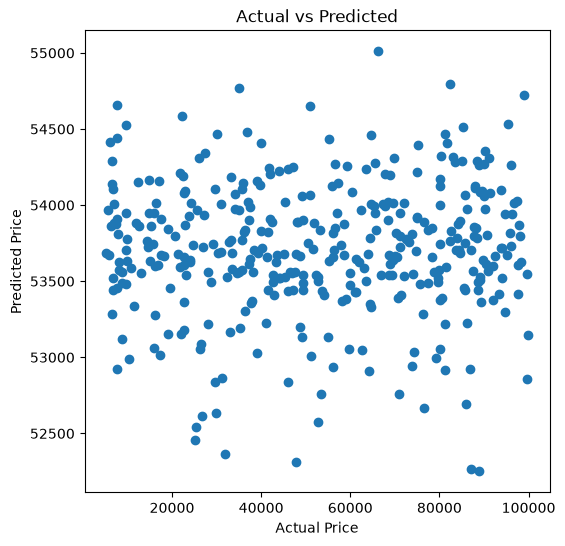

In [186]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

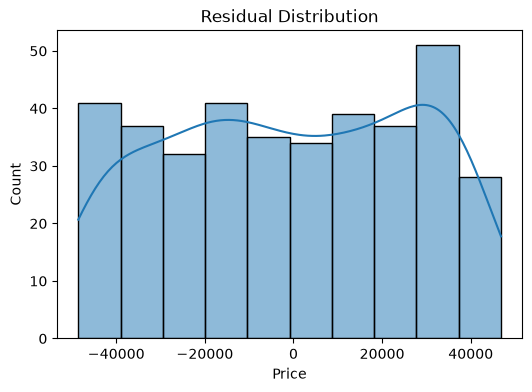

In [187]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()